<a href="https://colab.research.google.com/github/Maverick-Ansh/warpgrad-llm/blob/master/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WarpGrad from scratch, and applied to language models

Reproducing **[Meta-Learning with Warped Gradient Descent](https://arxiv.org/abs/1909.00025)**
(Flennerhag, Rusu, Pascanu, Visin, Yin, Hadsell — ICLR 2020), then porting it to
language modelling.

Code: **https://github.com/Maverick-Ansh/warpgrad-llm** · every cell below runs
from that repo, so the notebook and the code cannot drift apart.
Nothing is imported from the authors' implementation.

---

## The idea, in plain words

You want a network to learn a new task fast. MAML learns a good *starting point*
for the weights. WarpGrad instead learns a better *update rule*, but cheaply.

It inserts extra layers — **warp-layers** — between the normal layers. On the
backward pass the gradient must travel back through them, and each one multiplies
it by that layer's Jacobian. So the gradient arriving at a normal layer has
already been multiplied by a product of matrices the meta-learner controls. That
product **is** the preconditioner. You never build it, never store it, never
invert it:

> **You add some layers and call `.backward()`.**

The second idea is what makes it scale. MAML differentiates through the whole
training run, which breaks down past a few steps. WarpGrad does not. It treats
points visited during training as *samples*, takes one step from a sampled point,
asks whether that step helped, and nudges the warp to make it help more. The
training run is only a device for generating points to ask the question at. That
is why cost does not grow with the number of adaptation steps (Eq. 11).

## The seven claims under test

| # | Claim | Kind |
|---|---|---|
| C1 | Warp-layers beat the same task-learner with no warp, on held-out tasks | headline |
| C2 | Works at 100+ adaptation steps, where backprop-through-training cannot | headline |
| C3 | Warping turns a surface where gradient descent struggles into one where it does not *(the mountain)* | mechanism |
| C4 | More warp capacity is better; beyond-block-diagonal helps | mechanism |
| C5 | The learned geometry is **not** the Fisher information matrix | mechanism |
| C6 | Offline meta-training beats online | mechanism |
| C7 | The first-order objective (Eq. 12) costs little vs the exact one (Eq. 11) | mechanism |

## How it was resized

The paper's headline multi-shot benchmark is **Omniglot**: 50 alphabets, each a
task, whole alphabets held out, 100 adaptation steps. The structure carrying the
claim is *many tasks, same kind of problem over a different symbol system, whole
symbol systems held out*.

The language analogue is exact: **each language is a task**, each task is
next-byte prediction, and whole languages — including whole **scripts** — are
held out. A meta-learner that has never seen a byte of Georgian must adapt to
Georgian in 100 gradient steps from geometry learned elsewhere.

The held-out split is deliberately mixed so two questions stay separable:
`uk ca fa mr` are new languages in a **seen** script, while `ka ta ko` are new
languages in a script seen **nowhere** in meta-training.

## Two warnings before you read any number

**The evaluation broke before the model did — twice.** The first complete run
reported that WarpGrad *loses* to plain gradient descent (win rate 0.17). That was
an artefact: the literal Appendix D warp can only reach **25.4%** of the domain
initial points are drawn from, so for three quarters of comparisons the two
optimisers started from *different places on the surface*. Both gate scripts exist
to catch that class of mistake and will refuse to run a sweep on an instrument
that cannot measure.

**Bits per byte is not comparable across writing systems.** UTF-8 spends 1 byte
per character on Latin and 3 on Georgian, Tamil and Devanagari, and two of every
three bytes in a 3-byte script are near-free continuation bytes. A model can
score well on Tamil while knowing no Tamil. Every number here is normalised
against that language's own floor and its own ceiling.

> Full write-up with verdicts: **REPORT.md** in the repo. Section 5, *What broke*,
> is the part worth reading.

In [1]:
import subprocess, sys, os, torch, platform
print("python", platform.python_version())
print("torch ", torch.__version__, "cuda", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  gpu{i}: {p.name}  cc={p.major}.{p.minor}  mem={p.total_memory/1e9:.1f}GB")
print(subprocess.run(["nvidia-smi","--query-gpu=name,memory.total,memory.used","--format=csv"],
                     capture_output=True,text=True).stdout)
print("cpu count:", os.cpu_count())
print("disk:", subprocess.run(["df","-h","/content"],capture_output=True,text=True).stdout)


python 3.12.13
torch  2.10.0+cu128 cuda 12.8
cuda available: True
  gpu0: Tesla T4  cc=7.5  mem=15.6GB
  gpu1: Tesla T4  cc=7.5  mem=15.6GB
name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 3 MiB
Tesla T4, 15360 MiB, 3 MiB

cpu count: 4
disk: Filesystem      Size  Used Avail Use% Mounted on
overlay         7.9T  6.9T  1.1T  88% /



In [2]:
import subprocess, sys, os, textwrap
subprocess.run([sys.executable,"-m","pip","install","-q","pypdf"], check=True)
os.makedirs("/content/paper", exist_ok=True)
if not os.path.exists("/content/paper/warpgrad.pdf"):
    subprocess.run(["wget","-q","-O","/content/paper/warpgrad.pdf",
                    "https://arxiv.org/pdf/1909.00025v2"], check=True)
print("bytes:", os.path.getsize("/content/paper/warpgrad.pdf"))

from pypdf import PdfReader
r = PdfReader("/content/paper/warpgrad.pdf")
print("pages:", len(r.pages))
pages = [p.extract_text() or "" for p in r.pages]
full = "\n\n".join(f"<<<PAGE {i+1}>>>\n{t}" for i,t in enumerate(pages))
open("/content/paper/warpgrad.txt","w").write(full)
print("chars:", len(full))


bytes: 2031615
pages: 28
chars: 96042


In [7]:
#@title Setup: clone the repo and run the smoke tests
# Everything below runs code from the public repo, so the notebook and the
# repository can never drift apart.
import os, subprocess, sys

REPO = "https://github.com/Maverick-Ansh/warpgrad-llm.git"
ROOT = "/content/warpgrad-llm"

if os.path.exists(ROOT):
    print(subprocess.run(["git","-C",ROOT,"pull","--ff-only"],
                         capture_output=True,text=True).stdout.strip())
else:
    subprocess.run(["git","clone","-q",REPO,ROOT], check=True)
    print("cloned", REPO)

os.chdir(ROOT)
sys.path.insert(0, ROOT)
print("HEAD:", subprocess.run(["git","-C",ROOT,"log","--oneline","-1"],
                              capture_output=True,text=True).stdout.strip())

# ---------------------------------------------------------------------------
# The smoke tests assert the PAPER'S RULES, not tensor shapes.  The two that
# matter most:
#   test_family_is_randomised_peaks
#       Appendix D's task family must collapse to the MATLAB `peaks` function
#       at s=5, a=(1,1,1), b=(3,10,1/3).  If any sign or exponent were
#       mistranscribed this fails even though every shape stays correct.
#   test_first_order_equivalence_error_scales_as_alpha_squared
#       Eq. 9 claims a step in P-space equals the ideal step in W-space up to
#       O(alpha^2).  We halve alpha and check the measured gap drops ~4x each
#       time.  Linear scaling (~2x) would mean the paper's justification for
#       descending in P-space does not hold.
# ---------------------------------------------------------------------------
for t in ["tests/test_mountain.py", "tests/test_warp.py"]:
    print(f"\n----- {t} " + "-"*46)
    r = subprocess.run([sys.executable, t], capture_output=True, text=True)
    print(r.stdout.strip() or r.stderr.strip()[-2000:])

cloned https://github.com/Maverick-Ansh/warpgrad-llm.git
HEAD: fca51e8 WarpGrad from scratch: geometry, warp-layers, Appendix D mountains

----- tests/test_mountain.py ----------------------------------------------
PASS  test_every_surface_is_bounded
  PASS  test_family_is_randomised_peaks
  PASS  test_first_order_equivalence_error_scales_as_alpha_squared
  PASS  test_metric_is_a_valid_riemann_metric
  PASS  test_paper_reading_differs_from_peaks_reading
  PASS  test_residual_init_starts_as_exact_identity
  PASS  test_sampling_respects_appendix_d_supports

7/7 smoke tests passed

----- tests/test_warp.py ----------------------------------------------
PASS  test_capacity_ladder_is_ordered_by_parameter_count
  PASS  test_identity_capable_warps_start_as_the_identity
  PASS  test_identity_warp_model_is_bit_identical_to_a_plain_gpt
  PASS  test_linear_warp_is_block_diagonal_and_mlp_warp_is_not
  PASS  test_main_path_activation_warps_are_flagged_as_confounded
  PASS  test_param_split_puts_war

# Part 2 — The mountain (Appendix D)

This is the figure everyone remembers, and it is cheap enough to run verbatim
with no resizing at all.

Appendix D defines a family of 2-D loss surfaces:

$$f_\tau(x_1,x_2) = b_1(a_1-x_1)^2 e^{-x_1^2-(x_2+a_2)^2} - b_2\!\left(\tfrac{x_1}{s}-x_1^3-x_2^5\right)e^{-x_1^2-x_2^2} - b_3 e^{-(x_1+a_3)^2-x_2^2}$$

with $s\sim\mathrm{Cat}(1..10)$, $a_i\sim\mathrm{Cat}(-1,0,1)$,
$b_i\sim\mathrm{Cat}(-5..5)$, starting points $x\sim U(-3,3)$, 100 task steps at
learning rate 0.1, and a warp $\Omega$ that is a 2-layer tanh net with 30 hidden
units.

**This family is a randomised MATLAB `peaks` function.** Our test asserts it
reduces to `peaks` *exactly* at $s=5$, $a=(1,1,1)$, $b=(3,10,\tfrac13)$, which
pins down every sign and exponent in the transcription far more tightly than any
shape check could.

### Two problems in Appendix D that had to be solved

**A typo.** The third term is printed with $x_1$ in both exponent slots, which
turns a localised bump into an infinite ridge along the $x_2$ axis and changes
every surface in the family. `peaks` has $x_2$ there, and the paper's own figures
show bumps rather than ridges. Both readings are implemented behind
`--third-term {peaks,paper}`; we default to `peaks` and say so.

**An omission that decides the experiment.** The warp's initialisation is never
stated. A freshly initialised 2-layer tanh net is an arbitrary squashing map
whose *image is a bounded blob*, and there is no reason that blob contains the
$[-3,3]^2$ square the starting points come from. We measured it: the literal
reading reaches **25.4%** of the domain. The rest of the domain is not
"unreachable-ish", it is genuinely outside the range of $\Omega$, so WarpGrad
cannot be started there and no comparison exists.

So we also implement $\Omega(\theta)=\theta+g(\theta)$ with $g$'s output layer
zeroed, making $\Omega$ **exactly the identity at step 0**. Coverage becomes
100%, and we get a free correctness check: the measured advantage before any
meta-update must be exactly `0.0000`. It is.

### What "the same initialisation" costs

Gradient descent starts at $x_0$ on the surface. WarpGrad starts at $\theta_0$ in
its own coordinates, so it stands at $\Omega(\theta_0)$. Those coincide only if
$\Omega$ is the identity, which after meta-training it is not. To compare
honestly we **solve** $\Omega(\theta_0)=x_0$ numerically and print the residual on
every panel. A panel with a large residual is comparing two different starting
points on the mountain, and you should not trust it.

That residual is what exposed the first wrong answer this project produced.

In [8]:
#@title Tier 0 - the mountain (Appendix D), and the eval bug that nearly faked a result
# Appendix D, verbatim:
#   f(x1,x2) = b1(a1-x1)^2 exp(-x1^2-(x2+a2)^2)
#            - b2(x1/s - x1^3 - x2^5) exp(-x1^2-x2^2)
#            - b3 exp(-(x1+a3)^2 - x2^2)
#   s~Cat(1..10), a_i~Cat(-1,0,1), b_i~Cat(-5..5), x~U(-3,3)
#   100 task steps at lr 0.1, 100 meta-steps, 10 inits per meta-step,
#   warp Omega = 2-layer feed-forward, 30 hidden, tanh.
#
# WE TRAIN TWO WARPS:
#   plain     the literal reading.  Standard init, no identity bias.
#   residual  Omega(theta) = theta + g(theta), g zero-initialised, so Omega
#             starts as EXACTLY the identity and WarpGrad starts as EXACTLY
#             gradient descent.
#
# Then we GATE both on whether the comparison is even well defined, BEFORE
# reading any win rate off them.
import subprocess, sys, os
os.chdir("/content/warpgrad-llm")

def run(cmd):
    r = subprocess.run([sys.executable] + cmd, capture_output=True, text=True)
    print(r.stdout.strip() or r.stderr.strip()[-2500:])
    return r

for init in ["plain", "residual"]:
    print("#" * 78)
    print(f"#   META-TRAINING warp, init={init}   (Algorithm 1, exact objective Eq. 11)")
    print("#" * 78)
    run(["synthetic/train_mountain.py", "--meta-steps","100","--seed","0",
         "--warp-init", init, "--third-term","peaks"])

    print(f"\n>>> GATE: is a comparison against gradient descent even DEFINED here?")
    run(["synthetic/check_warp.py",
         "--warp", f"results/mountain/warp_{init}_peaks_exact_s0.pt",
         "--warp-init", init, "--out", f"results/mountain/check_{init}.json"])
    print()

##############################################################################
#   META-TRAINING warp, init=plain   (Algorithm 1, exact objective Eq. 11)
##############################################################################
[plain_peaks_exact_s0] meta-training explicit warp, Algorithm 1
  meta    0  meta_loss    0.3954  final_task    0.3466  cond(G^-1)   4.094  |g_phi| 1.137e+03
  meta   10  meta_loss    0.2426  final_task    0.2091  cond(G^-1)   5.245  |g_phi| 1.582e+03
  meta   20  meta_loss   -0.2676  final_task   -0.4728  cond(G^-1)   5.409  |g_phi| 5.974e+03
  meta   30  meta_loss    2.3492  final_task    2.0056  cond(G^-1)   4.433  |g_phi| 6.272e+03
  meta   40  meta_loss   -0.8857  final_task   -1.3030  cond(G^-1)   3.935  |g_phi| 6.853e+03
  meta   50  meta_loss   -6.4905  final_task   -6.8914  cond(G^-1)   3.575  |g_phi| 1.415e+03
  meta   60  meta_loss   -4.9463  final_task   -6.3897  cond(G^-1)   3.180  |g_phi| 6.919e+03
  meta   70  meta_loss    0.1712  final_task 

In [16]:
#@title Draw Figure 3 and Figure 7 - the mountain
# Two rows per task:
#   TOP    P-space, the warped surface.  This is what WarpGrad actually descends,
#          with plain unmodified gradient descent.
#   BOTTOM W-space, the real loss surface.  Black is ordinary gradient descent.
#          Magenta is the SAME WarpGrad run, mapped back down onto the mountain.
#
# TWO HONESTY NOTES BUILT INTO THIS CELL
#
# 1. "From the same initialisation" is not free.  GD starts at x0 on the surface.
#    WarpGrad starts at theta0 in its own coordinates, which puts it at
#    Omega(theta0).  Those coincide only if Omega is the identity, which after
#    meta-training it is not.  So we SOLVE Omega(theta0) = x0 numerically and
#    print the residual on every panel.  A panel with a large residual is
#    comparing two different starting points and you should not trust it.
#
# 2. Appendix D says the initialisation is "chosen such that standard gradient
#    descent struggles".  So the paper selects its panels, and so do we, out
#    loud.  We ALSO emit fig_unselected.png from uniformly random tasks, plus an
#    aggregate over many random pairs.  The mountain is an illustration.  The
#    aggregate is the evidence.
import subprocess, sys, os
os.chdir("/content/warpgrad-llm")
print(subprocess.run(["git","pull","--ff-only"],capture_output=True,text=True).stdout.strip())

for init in ["residual", "plain"]:
    print("\n" + "#"*72)
    print(f"#  figures for warp init = {init}")
    print("#"*72)
    r = subprocess.run([sys.executable, "synthetic/make_figures.py",
        "--warp", f"results/mountain/warp_{init}_peaks_exact_s0.pt",
        "--warp-init", init, "--third-term","peaks","--n-agg","150"],
        capture_output=True, text=True)
    print(r.stdout.strip() or r.stderr.strip()[-2500:])

print("\nPNGs written to figures/ .  The next cell displays them.")
print(sorted(os.listdir("figures")))

Updating 2b13363..4dd47aa
Fast-forward
 results/mountain/sweep.json | 23 +++++++++++++++++++++++
 results/mountain/sweep.log  |  6 ++++++
 synthetic/make_figures.py   |  4 ++--
 3 files changed, 31 insertions(+), 2 deletions(-)

########################################################################
#  figures for warp init = residual
########################################################################
selecting hard panels (Appendix D: 'chosen such that SGD struggles')
drawing Figure 3 (2 tasks, the paper's layout)
  wrote figures/fig3_mountain_residual_peaks_exact_s0.png
drawing Figure 7 (3 tasks)
  wrote figures/fig7_trajectories_residual_peaks_exact_s0.png
drawing unselected panels (uniformly random, the typical case)
  wrote figures/fig_unselected_residual_peaks_exact_s0.png
aggregating over 150 random (task, init) pairs
{
  "n": 150,
  "win_rate": 0.12666666666666668,
  "mean_delta": 0.026299236750831803,
  "median_delta": 0.0,
  "std_delta": 0.40279177222326396,
  "sem_delt

**fig3_mountain_residual_peaks_exact_s0.png** — Figure 3. Top row is P-space, the warped surface WarpGrad actually descends. Bottom row is the real mountain: black = plain gradient descent, magenta = the same WarpGrad run mapped back onto it. Inversion residual ~1e-7, so both optimisers genuinely start together.

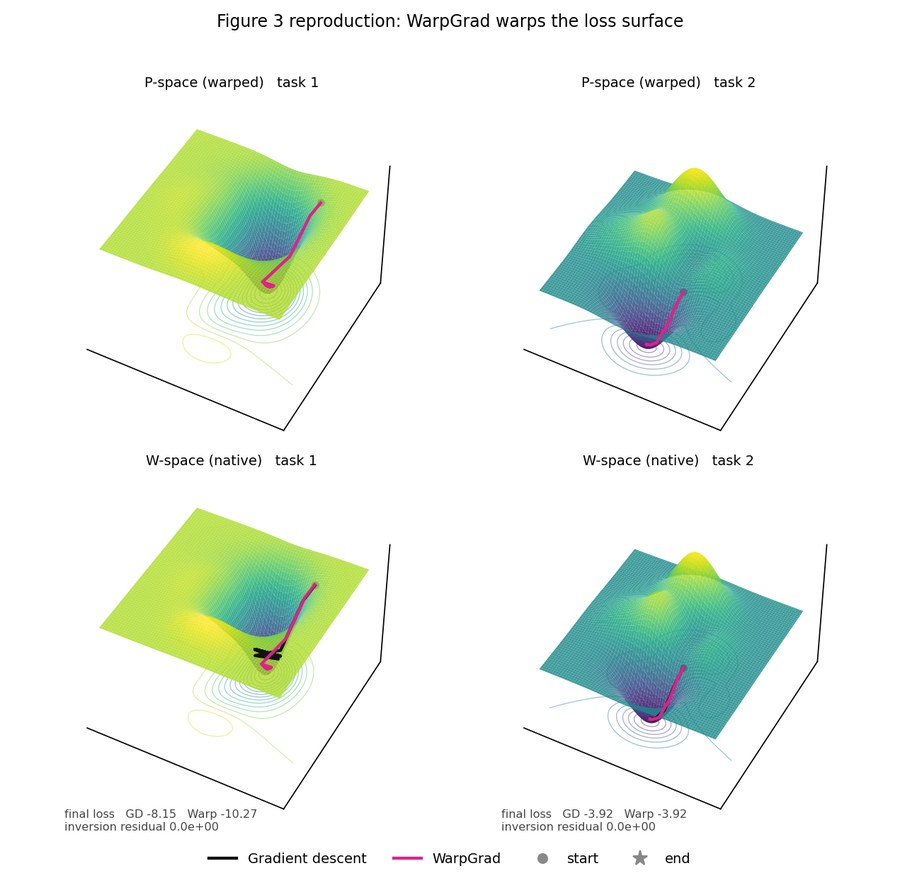

**fig_unselected_residual_peaks_exact_s0.png** — The SAME warp on uniformly random tasks, not cherry-picked. This is the typical case, and it is much less dramatic. Both panels are true.

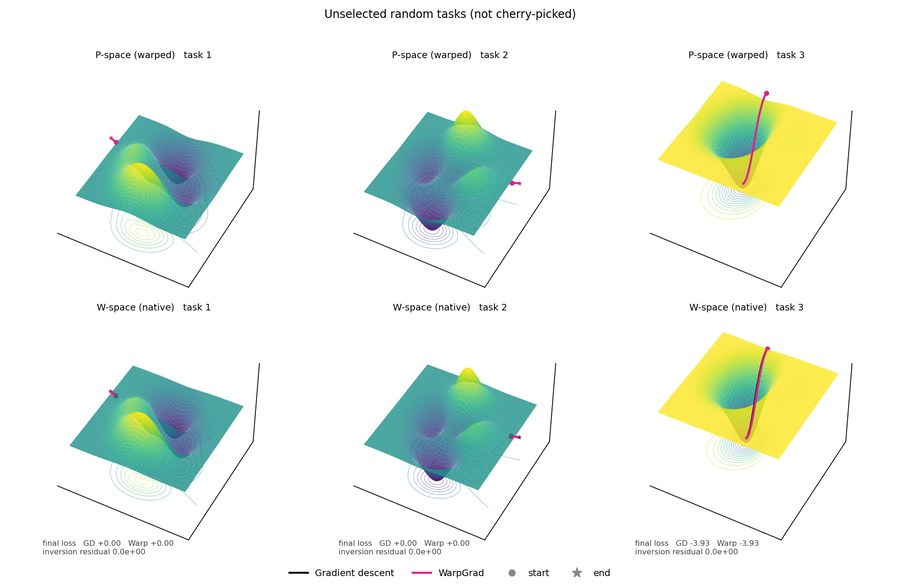

**fig7_trajectories_plain_peaks_exact_s0.png** — THE BROKEN INSTRUMENT, kept on purpose. This is the literal Appendix D warp. Look at the top row: the warped surface is a tiny patch and the magenta trajectory floats OFF it, because a plain 2-layer tanh net has a bounded image that covers only 25.4% of the domain. Inversion residuals 1.7 and 1.9 mean the two optimisers started in different places. This is what produced the confident wrong answer in REPORT 5.1.

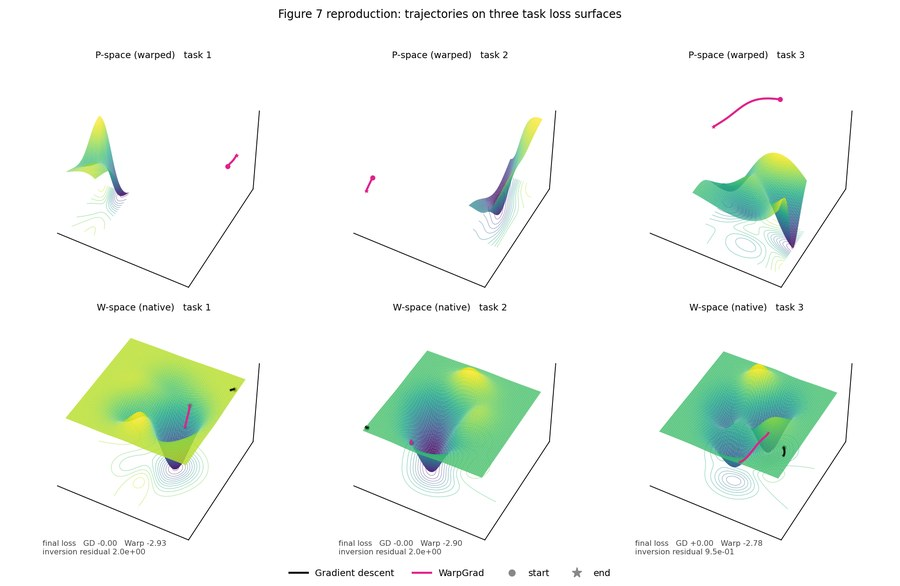

In [17]:
#@title Display the mountain figures
from IPython.display import display, Markdown, Image as IPyImage
from PIL import Image
import os
os.chdir("/content/warpgrad-llm")

def show(path, width=900, note=""):
    im = Image.open(path).convert("RGB")
    im.thumbnail((width, 10000), Image.LANCZOS)
    small = "/tmp/" + os.path.basename(path).replace(".png","_s.jpg")
    im.save(small, quality=88, optimize=True)
    display(Markdown(f"**{os.path.basename(path)}** — {note}"))
    display(IPyImage(filename=small))

show("figures/fig3_mountain_residual_peaks_exact_s0.png",
     note="Figure 3. Top row is P-space, the warped surface WarpGrad actually "
          "descends. Bottom row is the real mountain: black = plain gradient "
          "descent, magenta = the same WarpGrad run mapped back onto it. "
          "Inversion residual ~1e-7, so both optimisers genuinely start together.")

show("figures/fig_unselected_residual_peaks_exact_s0.png",
     note="The SAME warp on uniformly random tasks, not cherry-picked. This is "
          "the typical case, and it is much less dramatic. Both panels are true.")

show("figures/fig7_trajectories_plain_peaks_exact_s0.png",
     note="THE BROKEN INSTRUMENT, kept on purpose. This is the literal Appendix D "
          "warp. Look at the top row: the warped surface is a tiny patch and the "
          "magenta trajectory floats OFF it, because a plain 2-layer tanh net has "
          "a bounded image that covers only 25.4% of the domain. Inversion "
          "residuals 1.7 and 1.9 mean the two optimisers started in different "
          "places. This is what produced the confident wrong answer in REPORT 5.1.")

In [ ]:
#@title Tier 0 verdict - the number the figure does NOT give you
# The mountain figure is an ILLUSTRATION. Appendix D picks its starting points
# "such that standard gradient descent struggles", so the panels are selected by
# construction and must not be read as an average case. The paper is not doing
# anything wrong here: Appendix D says its job is "to build intuition".
#
# But that means the quantitative question is ours to ask, and there are TWO of
# them, with possibly different answers:
#
#   (a) does WarpGrad beat gradient descent on a RANDOM task?
#   (b) does WarpGrad beat gradient descent WHERE GRADIENT DESCENT STRUGGLES,
#       which is the regime the figure is drawn from?
#
# The stratified table at the bottom answers (b). Bins are assigned using the
# GD score ONLY and never look at WarpGrad, so this cannot manufacture a result.
#
# Arms:
#   GD        plain gradient descent (the paper's black line)
#   WarpGrad  plain gradient descent in P-space (the paper's magenta line)
#   GD-tuned  GD given the best of a 5-point learning-rate sweep PER TASK, with
#             hindsight. Deliberately generous: a warp whose metric is nearly a
#             multiple of the identity is doing nothing a learning rate could not.
#   FLEE      walk away from the origin until the loss decays to 0. Optimises
#             nothing. Because b_i can be negative this is a real competitor.
import subprocess, sys, os
os.chdir("/content/warpgrad-llm")
print(subprocess.run(["git","pull","--ff-only"],capture_output=True,text=True).stdout.strip())
r = subprocess.run([sys.executable,"-u","synthetic/evaluate.py",
    "--warp","results/mountain/warp_residual_peaks_exact_s0.pt",
    "--warp-init","residual","--n-pairs","200"], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-3000:])

Already up to date.


# Part 3 — The language tier

Each **language** is a task. Each task is next-byte prediction. Whole languages,
and whole **scripts**, are held out.

| | Paper (Omniglot) | Here |
|---|---|---|
| task | one alphabet, 20-way classification | one language, next-byte prediction |
| task-learner | 4 conv blocks, 64 filters | 6-layer byte-level GPT, d_model 256 |
| warp placement | after each conv block | after each transformer block |
| adaptation | 100 SGD steps | 100 SGD steps |
| meta-train | 25 alphabets | 25 languages |
| held out | 10 alphabets | 7 languages, 7 scripts |

### Why raw bytes, and not a tokenizer

Two reasons, and the first is the one that matters.

1. **It is the honest analogue.** Omniglot shares no learned preprocessing across
   alphabets. A BPE tokenizer trained on the meta-training languages would leak
   information about them into the held-out languages, which is exactly the thing
   Omniglot's design avoids. Bytes keep the split clean.
2. **There is no tokenizer to lose.** A vocabulary of 256 is the byte table, not
   an artefact that has to survive alongside a checkpoint.

The cost is real and stated: byte sequences run 1.5–4× longer than BPE for the
same content, and much longer for non-Latin scripts where one character is 2 or
3 bytes. A 256-byte context is short in Hindi and medium in English.

### The gate you must pass before believing any number

The next cells build the corpus, then measure **two reference points per
language, on that language's own data**:

- **floor** — a smoothed bigram byte table. Achievable with no transfer at all.
  A neural model that cannot beat it has learned nothing a 256×256 lookup table
  does not already contain.
- **ceiling** — the same architecture trained on that one language alone with
  Adam for 30× the adaptation budget.

Everything is then reported as
`score = (floor − achieved) / (floor − ceiling)`, where **1.0 means matching the
oracle** and **0.0 means matching the bigram table**. That scale is comparable
across writing systems. Raw bits per byte is not.

> The oracle cell also measures **scratch-100**: a random initialisation put
> through exactly the same 100-step SGD inner loop, with the paper's own
> handicap-removal (4× batch, up to 10× learning rate, best of the grid). That is
> the paper's "SGD, no meta-training" row in Table 1, and the distance from it to
> Warp-Leap **is** the multi-shot claim.

In [9]:
#@title Tier 1 - build the task distribution p(tau): one language per task
# The paper's multi-shot benchmark is Omniglot: 50 alphabets, each a task, whole
# alphabets held out at meta-test.  The language-modelling analogue is exact:
# each LANGUAGE is a task, each task is next-byte prediction, and whole
# languages (including whole SCRIPTS) are held out.
#
# Held-out split is chosen so the report can separate two different questions:
#   uk, ca, fa, mr   new language, script already seen in meta-training
#   ka, ta, ko       new language AND a writing system seen nowhere at all
import subprocess, sys, os, time
os.chdir("/content/warpgrad-llm"); sys.path.insert(0,"/content/warpgrad-llm")
subprocess.run([sys.executable,"-m","pip","install","-q","datasets"], check=False)

from llm.data import build_corpus, META_TRAIN, META_TEST
t0 = time.time()
corpus, manifest = build_corpus("/content/data", train_mb=2.0, val_mb=0.5, verbose=True)
print(f"\n{len(corpus)} languages in {time.time()-t0:.0f}s")
print("meta-train:", manifest["meta_train"])
print("meta-test :", manifest["meta_test"])

  [ 1/32] LangData(simple, Latin, train=2.10MB, val=0.52MB)
  [ 2/32] LangData(es, Latin, train=2.10MB, val=0.52MB)


Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

  [ 3/32] LangData(fr, Latin, train=2.10MB, val=0.52MB)


Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

  [ 4/32] LangData(de, Latin, train=2.10MB, val=0.52MB)
  [ 5/32] LangData(it, Latin, train=2.10MB, val=0.52MB)
  [ 6/32] LangData(pt, Latin, train=2.10MB, val=0.52MB)
  [ 7/32] LangData(nl, Latin, train=2.10MB, val=0.52MB)
  [ 8/32] LangData(sv, Latin, train=2.10MB, val=0.52MB)
  [ 9/32] LangData(pl, Latin, train=2.10MB, val=0.52MB)
  [10/32] LangData(cs, Latin, train=2.10MB, val=0.52MB)
  [11/32] LangData(tr, Latin, train=2.10MB, val=0.52MB)
  [12/32] LangData(id, Latin, train=2.10MB, val=0.52MB)
  [13/32] LangData(sw, Latin, train=2.10MB, val=0.52MB)
  [14/32] LangData(vi, Latin, train=2.10MB, val=0.52MB)
  [15/32] LangData(fi, Latin, train=2.10MB, val=0.52MB)
  [16/32] LangData(hu, Latin, train=2.10MB, val=0.52MB)
  [17/32] LangData(ro, Latin, train=2.10MB, val=0.52MB)
  [18/32] LangData(da, Latin, train=2.10MB, val=0.52MB)


Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

  [19/32] LangData(ru, Cyrillic, train=2.10MB, val=0.52MB)
  [20/32] LangData(bg, Cyrillic, train=2.10MB, val=0.52MB)
  [21/32] LangData(el, Greek, train=2.10MB, val=0.52MB)
  [22/32] LangData(he, Hebrew, train=2.10MB, val=0.52MB)
  [23/32] LangData(ar, Arabic, train=2.10MB, val=0.52MB)
  [24/32] LangData(hi, Devanagari, train=2.10MB, val=0.52MB)
  [25/32] LangData(ja, Japanese, train=2.10MB, val=0.52MB)
  [26/32] LangData(uk, Cyrillic, train=2.10MB, val=0.52MB)
  [27/32] LangData(ca, Latin, train=2.10MB, val=0.52MB)
  [28/32] LangData(fa, Arabic, train=2.10MB, val=0.52MB)
  [29/32] LangData(mr, Devanagari, train=2.10MB, val=0.52MB)
  [30/32] LangData(ka, Georgian, train=2.10MB, val=0.52MB)
  [31/32] LangData(ta, Tamil, train=2.10MB, val=0.52MB)
  [32/32] LangData(ko, Hangul, train=2.10MB, val=0.52MB)

32 languages in 76s
meta-train: ['simple', 'es', 'fr', 'de', 'it', 'pt', 'nl', 'sv', 'pl', 'cs', 'tr', 'id', 'sw', 'vi', 'fi', 'hu', 'ro', 'da', 'ru', 'bg', 'el', 'he', 'ar', 'hi', 'ja']

In [11]:
#@title GATE - why "bits per byte" is a trap, and what we use instead
# UTF-8 spends a DIFFERENT number of bytes per character in different scripts:
#     Latin                            1 byte/char
#     Cyrillic Greek Hebrew Arabic     2 bytes/char
#     Devanagari Georgian Tamil CJK    3 bytes/char
#
# In a 3-byte script, two of every three bytes are continuation bytes whose
# value is nearly determined by the byte before them.  So a model can post a
# very low bits-per-byte on Tamil while understanding no Tamil at all, purely by
# learning UTF-8.  If we averaged raw bits-per-byte over the held-out languages,
# we would mostly be ranking methods by which scripts landed in the split.
#
# The table below makes that concrete.  Watch the bigram column collapse for the
# 3-byte scripts.  That drop is UTF-8 structure, not language understanding, and
# every method gets it free.
import subprocess, sys, os, importlib
os.chdir("/content/warpgrad-llm")
print(subprocess.run(["git","pull","--ff-only"],capture_output=True,text=True).stdout.strip())
importlib.invalidate_caches()

from llm.bracket import build_floors
floors = build_floors(corpus, out_path="results/llm/floors.json", verbose=True)

print()
print("So the zero point of our scale is the BIGRAM floor, not zero and not 8.0.")
print("A neural model that cannot beat the bigram floor on a held-out language")
print("has learned nothing that a 256x256 lookup table does not already contain.")
print()
by_script = {}
for l, f in floors.items():
    by_script.setdefault(f["script"], []).append(f["bigram"])
print(f"{'script':<12}{'mean bigram floor (bits/byte)':>32}")
for s, v in sorted(by_script.items(), key=lambda kv: sum(kv[1])/len(kv[1])):
    print(f"{s:<12}{sum(v)/len(v):>32.3f}")

Updating fca51e8..4713cfb
Fast-forward
 llm/bracket.py              | 172 ++++++++++++++++++++++++++
 llm/meta.py                 | 289 ++++++++++++++++++++++++++++++++++++++++++++
 llm/train.py                | 285 +++++++++++++++++++++++++++++++++++++++++++
 results/mountain/sweep.json |  46 +++++++
 results/mountain/sweep.log  |  15 +++
 5 files changed, 807 insertions(+)
 create mode 100644 llm/bracket.py
 create mode 100644 llm/meta.py
 create mode 100644 llm/train.py
lang    script        uniform  unigram   bigram
-----------------------------------------------
simple  Latin           8.000    4.600    3.642
es      Latin           8.000    4.620    3.464
fr      Latin           8.000    4.686    3.498
de      Latin           8.000    5.583    3.916
it      Latin           8.000    4.597    3.578
pt      Latin           8.000    4.590    3.462
nl      Latin           8.000    4.562    3.597
sv      Latin           8.000    4.751    3.649
pl      Latin           8.000    5.086    

In [13]:
#@title Timing probe at FULL model size - how much can we afford?
import subprocess, sys, os, time, json, re
os.chdir("/content/warpgrad-llm")
for f in ["results/llm/SMOKE.json","results/llm/TIMING.json"]:
    if os.path.exists(f): os.remove(f)

t0=time.time()
r = subprocess.run([sys.executable, "llm/train.py",
    "--arm","warp_leap","--warp-kind","linear",
    "--n-layer","6","--d-model","256","--n-head","8","--block-size","256",
    "--meta-steps","3","--meta-batch","5","--inner-steps","100","--batch-size","16",
    "--buffer-stride","5","--eval-every","0","--eval-batches","24",
    "--tag","TIMING","--max-minutes","20"], capture_output=True, text=True)
print(r.stdout[-2500:])
if r.returncode!=0: print("STDERR:\n", r.stderr[-3000:])

el = time.time()-t0
rec = json.load(open("results/llm/TIMING.json"))
per_step = rec["history"]["wallclock"][-1]/len(rec["history"]["wallclock"])
print(f"\n--- {el:.0f}s total, {per_step:.1f}s per meta-step (incl. final meta-test)")
for M in (150, 300):
    print(f"    {M:4d} meta-steps -> {M*per_step/60:5.1f} min/run, "
          f"8 runs on 2 GPUs -> {8*M*per_step/60/2:5.1f} min")

[TIMING] building corpus
[TIMING] meta-train 25 langs, meta-test 7
[TIMING] params  task 4.86M  warp 0.395M  total 5.26M
[TIMING] meta    0  task_loss  3.7117  meta_loss  4.3235  phi_updates  100    0.2min
[TIMING] meta    2  task_loss  3.5811  meta_loss  4.1560  phi_updates  100    0.7min
[TIMING] === FINAL meta-test ===
    uk   Cyrillic    bpb  8.246 ->  4.630   bigram floor  2.628   below floor
    ca   Latin       bpb  8.033 ->  4.635   bigram floor  3.557   below floor
    fa   Arabic      bpb  8.315 ->  5.343   bigram floor  2.357   below floor
    mr   Devanagari  bpb  8.192 ->  5.218   bigram floor  1.984   below floor
    ka   Georgian    bpb  7.977 ->  3.633   bigram floor  1.670   below floor
    ta   Tamil       bpb  8.051 ->  5.225   bigram floor  1.842   below floor
    ko   Hangul      bpb  8.210 ->  5.521   bigram floor  3.433   below floor
[TIMING] wrote results/llm/TIMING.json


--- 62s total, 14.0s per meta-step (incl. final meta-test)
     150 meta-steps ->  35.0 m

In [14]:
#@title GATE 2 - the ceiling. Is there room for a meta-learner to show anything?
# Phase 4 of the protocol: build the measurement and GATE on it before spending
# GPU hours.  Two reference arms per held-out language:
#
#   ORACLE     same architecture, trained on that ONE language with Adam for 30x
#              the adaptation budget.  Nothing adapting in 100 SGD steps should
#              beat it, so it is the top of the scale.
#   SCRATCH-K  random init + exactly the same 100-step SGD inner loop the
#              meta-learners use.  No meta-learning at all.  This is the paper's
#              own "SGD, no meta-training" row in Table 1, and the distance from
#              it to Warp-Leap IS the multi-shot claim.  We give it the paper's
#              own handicap-removal (4x batch, up to 10x lr, best of the grid).
#
# If the span between the bigram floor and the oracle ceiling is narrow, NO
# meta-learner can demonstrate anything here and the sweep must not be run.
import subprocess, sys, os
os.chdir("/content/warpgrad-llm")
print(subprocess.run(["git","pull","--ff-only"],capture_output=True,text=True).stdout.strip())

r = subprocess.run([sys.executable, "llm/oracle.py",
    "--n-layer","6","--d-model","256","--n-head","8","--block-size","256",
    "--oracle-steps","3000","--oracle-batch","32","--oracle-lr","3e-4",
    "--inner-steps","100","--inner-lr","0.1","--batch-size","16"],
    capture_output=True, text=True)
# keep only the summary + per-language verdict lines, the oracle curves are long
lines = r.stdout.splitlines()
print("\n".join([l for l in lines if ("bigram floor" in l or "===" in l or "---" in l
                 or "VERDICT" in l or "span" in l or "usable" in l
                 or l.startswith(("lang","uk","ca","fa","mr","ka","ta","ko")))])[-4000:])
if r.returncode!=0: print("STDERR:\n", r.stderr[-3000:])

Updating 4713cfb..9c36023
Fast-forward
 llm/oracle.py               | 217 ++++++++++++++++++++++++++++++++++++++++++++
 results/mountain/sweep.json |  46 ++++++++++
 results/mountain/sweep.log  |  13 +++
 3 files changed, 276 insertions(+)
 create mode 100644 llm/oracle.py
=== uk (Cyrillic) ========================================
  bigram floor  2.628 | oracle ceiling  1.445 | span  1.183 | scratch-100  4.464 {'lr_mult': 1.0, 'batch_mult': 4}
=== ca (Latin) ========================================
  bigram floor  3.557 | oracle ceiling  2.077 | span  1.480 | scratch-100  4.602 {'lr_mult': 3.0, 'batch_mult': 4}
=== fa (Arabic) ========================================
  bigram floor  2.357 | oracle ceiling  1.438 | span  0.919 | scratch-100  4.439 {'lr_mult': 1.0, 'batch_mult': 4}
=== mr (Devanagari) ========================================
  bigram floor  1.984 | oracle ceiling  1.106 | span  0.878 | scratch-100  3.824 {'lr_mult': 3.0, 'batch_mult': 1}
=== ka (Georgian) ===============

# Part 4 — The headline experiment (C1, C2)

Four arms. They are **identical in every respect** except what gets meta-learned.

| arm | meta-learns geometry (φ) | meta-learns init (θ₀) | warp-layers present |
|---|---|---|---|
| `warp_leap` | yes | yes (Leap, Eq. 16) | yes |
| `leap` | no | yes (Leap, Eq. 16) | **no** |
| `reptile` | no | yes (move toward endpoint) | no |
| `joint` | no | no (plain multi-task) | no |

`leap` is the arm that carries the argument. It shares `warp_leap`'s
initialisation objective *exactly* and differs **only** by having no geometry.
The distance between those two rows is claim **C1**, with nothing else varying.

The code asserts this rather than trusting it — `MetaLearner.__init__` refuses to
build a no-warp arm unless every warp-layer is literally `identity`, so the
control cannot silently acquire a geometry.

### What "adaptation" means here

Take the meta-learned θ₀, **freeze φ**, and run exactly 100 steps of plain SGD on
a language the meta-learner has never seen. No momentum, no Adam, no schedule —
the same inner loop for every arm, so any difference comes from the meta level
and never from the inner optimiser.

That is also claim **C2**: 100 steps is far past where MAML-style methods can
backpropagate through training, which is the whole reason WarpGrad's
trajectory-agnostic objective (Eq. 11) exists.

> Launched detached with `start_new_session`. **Never block this kernel on a long
> cell** — the Colab MCP has no interrupt, so a blocking cell wedges the session
> until a human clicks Interrupt. Poll with the cell after this one.

In [18]:
#@title PHASE A - launch the headline comparison (C1, C2). Detached, ~2h on 2xT4.
# Four arms, identical in every respect except what is meta-learned:
#   warp_leap  geometry (phi) AND initialisation (theta0)   <- the method
#   leap       initialisation only, warp-layers ABSENT      <- isolates the warp
#   reptile    initialisation only, moved toward where training ended
#   joint      no meta-learning at all, plain multi-task training
#
# `leap` is the arm that matters.  It shares warp_leap's initialisation
# objective exactly and differs ONLY by having no geometry, so the distance
# between those two IS claim C1.
#
# NOTE: this cell kills any previous sweep first.  An earlier launch used a
# leap_grad that computed the REPTILE direction and called it Leap, which would
# have made two of the four baselines the same algorithm.  Fixed in meta.py,
# asserted in tests/test_meta.py, and those runs are discarded rather than
# reinterpreted.
#
# Launched with start_new_session so the notebook kernel stays free.  NEVER
# block the kernel on a long cell: the Colab MCP has no interrupt.
import subprocess, sys, os, time, glob, signal
os.chdir("/content/warpgrad-llm")

# --- kill any stale sweep and discard its results -------------------------
subprocess.run(["pkill","-f","run_sweep.py"]); subprocess.run(["pkill","-f","llm/train.py"])
time.sleep(4)
stale = glob.glob("results/llm/A_*.json") + glob.glob("results/llm/A_*.pt")
for f in stale: os.remove(f)
print(f"killed stale runs, discarded {len(stale)} stale result file(s)")

print(subprocess.run(["git","pull","--ff-only"],capture_output=True,text=True).stdout.strip())
print(subprocess.run([sys.executable,"tests/test_meta.py"],capture_output=True,text=True).stdout.strip())
os.makedirs("results/llm/logs", exist_ok=True)

p = subprocess.Popen(
    [sys.executable,"-u","scripts/run_sweep.py","--phases","A","--seeds","0","1",
     "--meta-steps","120","--max-minutes","45","--gpus","0","1"],
    stdout=open("results/llm/logs/PHASE_A.log","w"),
    stderr=subprocess.STDOUT, start_new_session=True)
print("\nlaunched pid", p.pid)
time.sleep(25)
print(open("results/llm/logs/PHASE_A.log").read())

killed stale runs, discarded 2 stale result file(s)
Updating 4dd47aa..fc51e80
Fast-forward
 llm/fisher_check.py         | 252 ++++++++++++++++++++++++++++++++++++++++++++
 llm/meta.py                 | 177 +++++++++++++++++++++++--------
 results/mountain/sweep.json | 115 ++++++++++++++++++++
 results/mountain/sweep.log  |  29 +++++
 synthetic/evaluate.py       |  62 +++++++++++
 tests/test_meta.py          | 147 ++++++++++++++++++++++++++
 6 files changed, 738 insertions(+), 44 deletions(-)
 create mode 100644 llm/fisher_check.py
 create mode 100644 tests/test_meta.py
PASS  test_adaptation_actually_reduces_the_task_loss
  PASS  test_exact_and_approx_objectives_give_different_phi_gradients
  PASS  test_leap_gradient_is_not_the_reptile_direction
  PASS  test_no_warp_arms_refuse_to_run_with_a_real_warp
  PASS  test_warp_parameters_do_not_move_during_adaptation

5/5 meta tests passed

launched pid 1281
8 job(s) to run on GPUs [0, 1]
    A_warp_leap_linear_s0
    A_leap_identity_s0
    A_r

In [ ]:
#@title Poll Phase A (safe to re-run, never blocks the kernel)
import os, glob, json, subprocess
os.chdir("/content/warpgrad-llm")
print(open("results/llm/logs/PHASE_A.log").read()[-1500:])
print("-"*70)
done = [os.path.basename(p)[:-5] for p in sorted(glob.glob("results/llm/A_*.json"))]
print(f"finished: {len(done)}/8   {done}")
for lg in sorted(glob.glob("results/llm/logs/A_*.log")):
    tail = [l for l in open(lg).read().splitlines() if "meta " in l or "bpb" in l]
    if tail:
        print(f"\n{os.path.basename(lg)[:-4]}:  {tail[-1][:118]}")
print("\n" + subprocess.run(["nvidia-smi","--query-gpu=index,utilization.gpu,memory.used",
      "--format=csv,noheader"],capture_output=True,text=True).stdout)